In [24]:
import math as m
class RunningMeanStd:
    def __init__(self):
        self.mean = 0.0
        self.S = 0.0      # running sum of squared devs
        self.count = 0

    def update(self, x):
        # x can be a list of new samples; here we do one at a time
        for r in x:
            self.count += 1
            delta = r - self.mean
            self.mean += delta / self.count
            delta2 = r - self.mean
            self.S += delta * delta2

    @property
    def variance(self):
        return self.S / self.count if self.count > 0 else 0.0

    @property
    def std(self):
        return m.sqrt(self.variance)

In [7]:
import unittest
import math as m

# Define the RunningMeanStd class as provided
class RunningMeanStd:
    def __init__(self):
        self.mean = 0.0
        self.S = 0.0      # running sum of squared devs
        self.count = 0

    def update(self, x):
        # x can be a list of new samples; here we do one at a time
        for r in x:
            self.count += 1
            delta = r - self.mean
            self.mean += delta / self.count
            delta2 = r - self.mean
            self.S += delta * delta2

    @property
    def variance(self):
        return self.S / self.count if self.count > 0 else 0.0

    @property
    def std(self):
        return m.sqrt(self.variance)

# Unit tests for RunningMeanStd
class TestRunningMeanStd(unittest.TestCase):
    def test_mean_variance_std(self):
        data = [1, 2, 3, 4, 5]
        rms = RunningMeanStd()
        rms.update(data)
        
        # Known values
        expected_mean = sum(data) / len(data)
        expected_variance = sum((x - expected_mean)**2 for x in data) / len(data)
        expected_std = m.sqrt(expected_variance)
        
        self.assertAlmostEqual(rms.mean, expected_mean, places=7)
        self.assertAlmostEqual(rms.variance, expected_variance, places=7)
        self.assertAlmostEqual(rms.std, expected_std, places=7)

    def test_incremental_vs_batch(self):
        data = [10, 20, 30, 40, 50]
        
        # Batch update
        rms_batch = RunningMeanStd()
        rms_batch.update(data)
        
        # Incremental update one by one
        rms_inc = RunningMeanStd()
        for x in data:
            rms_inc.update([x])
        
        self.assertAlmostEqual(rms_batch.mean, rms_inc.mean, places=7)
        self.assertAlmostEqual(rms_batch.variance, rms_inc.variance, places=7)

    def test_empty(self):
        rms = RunningMeanStd()
        self.assertEqual(rms.mean, 0.0)
        self.assertEqual(rms.variance, 0.0)
        self.assertEqual(rms.std, 0.0)

if __name__ == "__main__":
    unittest.main(argv=[''], exit=False)


...
----------------------------------------------------------------------
Ran 3 tests in 0.003s

OK


In [74]:
data = [1, 2, 3, 4, 5]
import random

# Generate a list of 10 random numbers between 1 and 6
data = [random.randint(1, 7) for _ in range(20)]
rms = [RunningMeanStd() for _ in range(10)]
print(f"Data = {data}")
print(f"mean data = {np.mean(data)}")
idx = 0
rms[idx].update(data)


expected_mean = sum(data) / len(data)
expected_variance = sum((x - expected_mean)**2 for x in data) / len(data)
expected_std = m.sqrt(expected_variance)
print(expected_std)
print(f"RMS {rms[idx].std}")

import numpy as np
data_n = [15]
rms[idx].update(data_n)

# Compute normalized advantage
raw_adv = data_n[0] - np.mean(data)
denom = max(rms[idx].std, 1e-3)   # or 1e-2
adv   = raw_adv/ denom
print(raw_adv)
adv*0.2*0.05

Data = [5, 3, 3, 6, 4, 1, 4, 7, 3, 4, 2, 1, 2, 7, 7, 4, 1, 2, 5, 1]
mean data = 3.6
2.009975124224178
RMS 2.0099751242241783
11.4


np.float64(0.0365251501321866)

In [66]:
import torch

class RobotDesignDist():
    """
    Joint distribution for robot design parameters.
    
    A robot design is parameterized by 5 elements:
      - Two discrete parameters (represented as a tuple, e.g. (d1, d2))
      - Three continuous parameters.
    
    The joint probability is modeled as:
    
         P(robot design) = P(discrete) * P(continuous | discrete)
    
    Inputs:
      - discrete_logits: Tensor of shape (N,), where N is the number of discrete combinations.
      - continuous_means: Tensor of shape (N, 3) giving the mean for the 3 continuous parameters per combination.
      - continuous_stds: Tensor of shape (N, 3) giving the std for the 3 continuous parameters per combination.
      - discrete_values: List of length N of tuples (each tuple is one discrete combination).
    """
    def __init__(self, discrete_logits,pressure_range, continuous_means, continuous_stds, discrete_values):
        super().__init__()
        self.discrete_logits = discrete_logits
        self.continuous_means = continuous_means
        self.continuous_stds = continuous_stds
        self.discrete_values = discrete_values
        self.pressure_range = pressure_range

    def get_distribution(self):
        # Build the discrete distribution.
        self.mixture_dist = torch.distributions.Categorical(logits=self.discrete_logits)
        # Create the base continuous distribution (Normal).
        self.base_normal = torch.distributions.Normal(self.continuous_means, self.continuous_stds)
        
        # Apply transforms:
        # 1. Sigmoid maps R -> (0, 1)
        # 2. AffineTransform with scale=0.1 maps (0,1) -> (0, 0.1)
        self.transforms = [torch.distributions.SigmoidTransform(), 
                      torch.distributions.AffineTransform(
                          loc=0, scale=self.pressure_range[1])]
        self.transformed_cont_dist = torch.distributions.TransformedDistribution(self.base_normal, self.transforms)
        
        # Wrap in an Independent to treat the last dimension as the event dimension.
        self.component_dist = torch.distributions.Independent(self.transformed_cont_dist, 1)
        # Create the joint mixture distribution.
        self.joint_dist = torch.distributions.MixtureSameFamily(
            mixture_distribution=self.mixture_dist,
            component_distribution=self.component_dist
        )
        return self.joint_dist

    def log_prob(self, value):
        return self.get_distribution().log_prob(value)

    def kl(self, other):
        # Compute KL divergence between two joint distributions.
        p_probs = F.softmax(self.discrete_logits, dim=0)
        q_probs = F.softmax(other.discrete_logits, dim=0)
        kl_discrete = torch.sum(p_probs * (torch.log(p_probs + 1e-8) - torch.log(q_probs + 1e-8)))
        
        # For the continuous part, we need to compute KL on the base distributions and account for the transforms.
        # Note: There is no simple closed-form for the KL of transformed distributions, so here we
        # compute the KL of the base Normal distributions (this is an approximation).
        p_cont = torch.distributions.Independent(torch.distributions.Normal(
            self.continuous_means, self.continuous_stds), 1)
        q_cont = torch.distributions.Independent(torch.distributions.Normal(
            other.continuous_means, other.continuous_stds), 1)
        kl_components = torch.distributions.kl_divergence(p_cont, q_cont)
        kl_continuous = torch.sum(p_probs * kl_components)
        
        return kl_discrete + kl_continuous

    def to_tensors(self):
        return {'discrete_logits': self.discrete_logits,
                'continuous_means': self.continuous_means,
                'continuous_stds': self.continuous_stds,
                'discrete_values': self.discrete_values}

    @classmethod
    def from_tensors(cls, tensors):
        return cls(tensors['discrete_logits'],
                   tensors['continuous_means'],
                   tensors['continuous_stds'],
                   tensors['discrete_values'])
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from itertools import product
import gym
import wandb
import math as m
# --- RobotDesignOptimizer Class ---
class RobotDesignOptimizer(nn.Module):
    def __init__(self,
                 cut_off_length,
                 design_space,
                 ent_decay_start,
                 ent_decay_end):
        """
        Optimizer for joint robot design.
        
        Parameters:
          - discrete_values: List of discrete combinations (e.g. [(1, 'A'), (2, 'B'), ...]).
          - init_pressure_means: Tensor of shape (N, 3) initial means.
          - init_pressure_stds: Tensor of shape (N, 3) initial standard deviations.
          - ent_decay_start, ent_decay_end: Steps for entropy schedule.
        """
        super().__init__()
        self.cut_off_length = cut_off_length
        self.no_chamber = design_space['no_chamber']
        self.chamber_length = design_space['chamber_length']
        self.thickness = design_space['thickness']
        self.pressure_range= design_space['pressure_range']
        self.exploration_end_t = ent_decay_end
        #number of possible combination of body parameters
        self.discrete_combinations = list(product(self.no_chamber, self.chamber_length,self.thickness))
        self.N = len(self.discrete_combinations)
        self.D = len(self.no_chamber)
        # Initialize discrete scores (which, when multiplied by beta, form logits).
        self.scores = torch.nn.Parameter(torch.zeros((self.N,), dtype=torch.float32), requires_grad=False)
        # Continuous parameters (not updated by gradients but via update() method).
        continuous_means_np = np.random.uniform(low=self.pressure_range[0], high=self.pressure_range[1], size=(self.N, self.D))
        self.continuous_means = torch.tensor(continuous_means_np, dtype=torch.float32)
        self.continuous_stds = torch.full((self.N , self.D), self.pressure_range.mean().item()/2) 
        self.beta = 0.0
        self.beta_min = 0.0
        self.beta_max = 5.0
        self.init_list_sample = 0
        self.pressure_grid_idx = 0
        self.baseline = torch.zeros(len(self.discrete_combinations), dtype=torch.float)
        self.beta_b   = 0.2            # smoothing factor for baseline

        # --- Grid phase setup ---
        p_min, p_max = float(self.pressure_range[0]), float(self.pressure_range[1])
        n_grid_steps=8
        pressure1_range = np.linspace(p_min, p_max, n_grid_steps)
        pressure2_range = np.linspace(p_min, p_max, n_grid_steps)
        self.pressure_grid = [(p1, p2) for p1 in pressure1_range for p2 in pressure2_range]  # size n_grid_steps^2

    def get_design_dist(self):
        # The discrete logits are computed as beta * scores.
        return RobotDesignDist(discrete_logits=self.beta * self.scores,
                               pressure_range = self.pressure_range,
                               continuous_means=self.continuous_means,
                               continuous_stds=self.continuous_stds,
                               discrete_values=self.discrete_combinations)

    def sample(self,t):
        target = self.target(t)
        robot_dist = self.get_design_dist()
        joint      = robot_dist.get_distribution()  

        if abs(target - np.log(self.N)) <= 1e-4: 
            discrete_idx = self.init_list_sample
            self.init_list_sample = (discrete_idx + 1) % len(self.discrete_combinations)
        else:
            discrete_idx = int(joint.mixture_distribution.sample().item())
        # Discrete values
        discrete_values = self.discrete_combinations[discrete_idx]
        # Continuous values
        component_dist = joint.component_distribution
        transformed_pressure_list = component_dist.sample()[discrete_idx]
        inversed_pressure_list = transformed_pressure_list
        
        for transform in reversed(robot_dist.transformed_cont_dist.transforms):
            inversed_pressure_list = transform.inv(inversed_pressure_list)


        return {'no_chamber': discrete_values[0],
                'chamber_length': discrete_values[1],
                'thickness': discrete_values[2],
                'pressure1': torch.clamp(inversed_pressure_list[0], min=self.pressure_range[0],max=self.pressure_range[1]),
                'pressure2': torch.clamp(inversed_pressure_list[1], min=self.pressure_range[0],max=self.pressure_range[1])} ### pressure_list is 'list' type then there is no .numpy()

In [67]:
# 1) Define your design space parameters
design_space = {
    "no_chamber": [1, 2],
    "chamber_length": list(np.linspace(20, 40, 11, dtype=int)),
    "thickness": list(np.linspace(2, 4, 5)),
    "pressure_range": torch.tensor([0.0, 0.3]),
}

# 2) Create optimizer instance
#    ent_decay_start/end and std_target schedule are just placeholders
opt = RobotDesignOptimizer([100],
                 design_space,
                 100,
                 1111)
# hook up example schedules
opt.target = lambda t: np.log(opt.N) + 1.0  # force going into stochastic immediately

# 3) Draw and print 20 samples at different timesteps
for t in [0, 10, 100, 1000]:
    print(f"\n=== t = {t} ===")
    for i in range(5):
        s = opt.sample(t)
        # ensure discrete values are ints, pressures are formatted as floats
        nc = int(s['no_chamber'])
        cl = int(s['chamber_length'])
        th = int(s['thickness'])
        p1 = s['pressure1']
        p2 = s['pressure2']
        print(
            f" Sample {i:2d}: no_chamber={nc:d}, "
            f"chamber_length={cl:d}, thickness={th:d}, "
            f"p1={p1:.3f}, p2={p2:.3f}"
        )


=== t = 0 ===
 Sample  0: no_chamber=1, chamber_length=38, thickness=2, p1=0.000, p2=0.000
 Sample  1: no_chamber=1, chamber_length=30, thickness=2, p1=0.270, p2=0.049
 Sample  2: no_chamber=1, chamber_length=22, thickness=2, p1=0.292, p2=0.163
 Sample  3: no_chamber=1, chamber_length=26, thickness=2, p1=0.145, p2=0.114
 Sample  4: no_chamber=2, chamber_length=26, thickness=3, p1=0.147, p2=0.146

=== t = 10 ===
 Sample  0: no_chamber=2, chamber_length=36, thickness=4, p1=0.141, p2=0.230
 Sample  1: no_chamber=2, chamber_length=34, thickness=2, p1=0.000, p2=0.204
 Sample  2: no_chamber=2, chamber_length=34, thickness=4, p1=0.184, p2=0.000
 Sample  3: no_chamber=1, chamber_length=20, thickness=4, p1=0.190, p2=0.000
 Sample  4: no_chamber=1, chamber_length=40, thickness=3, p1=0.168, p2=0.300

=== t = 100 ===
 Sample  0: no_chamber=2, chamber_length=24, thickness=4, p1=0.122, p2=0.300
 Sample  1: no_chamber=1, chamber_length=38, thickness=3, p1=0.065, p2=0.112
 Sample  2: no_chamber=1, ch

In [22]:
continuous_means_np = np.random.uniform(low=0, high=0.3, size=(3, 2))
continuous_means = torch.tensor(continuous_means_np, dtype=torch.float32)
continuous_means

tensor([[0.2854, 0.2097],
        [0.0140, 0.2172],
        [0.0857, 0.0843]])

In [21]:
pressure_range = np.array([0,0.3])
continuous_stds = torch.full((3, 2), pressure_range.mean().item()/4) 
continuous_stds

tensor([[0.0375, 0.0375],
        [0.0375, 0.0375],
        [0.0375, 0.0375]])

In [55]:
import torch
import torch.nn as nn
import torch.distributions as D
import numpy as np

class RobotDesignDistMulti(nn.Module):
    """
    Extended RobotDesignDist supporting:
      1) Mixture of K Gaussians per discrete combination.
      2) Beta distribution per continuous variable.
      3) Discrete bins + Gaussian jitter.
    """
    def __init__(self,
                 discrete_combinations,
                 pressure_range,
                 K=3,
                 n_bins=7,
                 jitter_std=0.02):
        super().__init__()
        self.discrete_combinations = discrete_combinations
        self.N = len(discrete_combinations)
        self.D = 2  # two pressures
        self.p_min, self.p_max = pressure_range
        # --- 1) Mixture of K Gaussians ---
        self.K = K
        # logits for mixture weights: (N, K)
        self.mix_logits = nn.Parameter(torch.zeros(self.N, K))
        # means and stds for each component: (N, K, D)
        self.means = nn.Parameter(torch.rand(self.N, K, self.D) * (self.p_max - self.p_min) + self.p_min)
        self.stds = nn.Parameter(torch.full((self.N, K, self.D), 0.05))
        # --- 2) Beta parameters for each design and pressure: (N, D)
        # initialize alpha,beta >1 for approximate unimodal
        self.beta_alpha = nn.Parameter(torch.ones(self.N, self.D) * 2.0)
        self.beta_beta = nn.Parameter(torch.ones(self.N, self.D) * 2.0)
        # --- 3) Discrete bins + jitter ---
        self.n_bins = n_bins
        self.bins = torch.linspace(self.p_min, self.p_max, n_bins)
        self.jitter_std = jitter_std

    def mixture_dist(self, idx):
        logits = self.mix_logits[idx]          # (K,)
        cat = D.Categorical(logits=logits)
        comps = D.Independent(D.Normal(self.means[idx], self.stds[idx]), 1)
        return D.MixtureSameFamily(cat, comps)

    def beta_dist(self, idx):
        a = self.beta_alpha[idx]  # (D,)
        b = self.beta_beta[idx]
        return D.Independent(D.Beta(a, b), 1)

    def bin_dist(self):
        # uniform categorical over bins
        return D.Categorical(logits=torch.zeros(self.n_bins))

    def sample(self, idx, mode="mixture"):
        """
        idx: int discrete index
        mode: 'mixture', 'beta', or 'bins'
        """
        if mode == "mixture":
            dist = self.mixture_dist(idx)
            x = dist.sample()                    # (D,)
        elif mode == "beta":
            dist = self.beta_dist(idx)
            u = dist.sample()                    # (D,) in [0,1]
            x = u * (self.p_max - self.p_min) + self.p_min
        elif mode == "bins":
            bin_cat = self.bin_dist()
            b = bin_cat.sample()                 # int
            center = self.bins[b]
            noise = torch.randn(self.D) * self.jitter_std
            x = center + noise
            x = torch.clamp(x, self.p_min, self.p_max)
        else:
            raise ValueError("Unknown mode")
        return x

# Example usage:
if __name__ == '__main__':
    design_combos = [(1,20,2),(1,40,2),(1,40,5),(2,20,2),(2,40,5)]
    rd = RobotDesignDistMulti(design_combos, pressure_range=(0.0,0.3))
    for idx in range(len(design_combos)):
        print("Design", design_combos[idx])
        print(" Mixture sample:", rd.sample(idx, mode='mixture'))
        print(" Beta sample:",    rd.sample(idx, mode='beta'))
        print(" Bins+noise sample:", rd.sample(idx, mode='bins'))
        print()


Design (1, 20, 2)
 Mixture sample: tensor([0.3510, 0.3258])
 Beta sample: tensor([0.1304, 0.2321])
 Bins+noise sample: tensor([0.1676, 0.1675])

Design (1, 40, 2)
 Mixture sample: tensor([0.1376, 0.1445])
 Beta sample: tensor([0.0878, 0.1860])
 Bins+noise sample: tensor([0.0044, 0.0046])

Design (1, 40, 5)
 Mixture sample: tensor([-0.0160,  0.2720])
 Beta sample: tensor([0.1570, 0.0248])
 Bins+noise sample: tensor([0.1560, 0.1264])

Design (2, 20, 2)
 Mixture sample: tensor([ 0.1927, -0.0069])
 Beta sample: tensor([0.0987, 0.1615])
 Bins+noise sample: tensor([0.2055, 0.1994])

Design (2, 40, 5)
 Mixture sample: tensor([0.0084, 0.1604])
 Beta sample: tensor([0.2329, 0.1777])
 Bins+noise sample: tensor([0.1403, 0.0848])



In [17]:
import torch
import torch.nn as nn
import torch.distributions as D
import numpy as np
from torch.distributions import MultivariateNormal, Categorical, MixtureSameFamily
from itertools import product
class RobotDesignDistCorrelated(nn.Module):
    def __init__(self, discrete_logits,pressure_range, continuous_means, rawL):
        super().__init__()
        self.discrete_logits = discrete_logits
        self.continuous_means = continuous_means
        self.raw_L = rawL
        self.pressure_range = pressure_range

    def get_distribution(self):
        # 1) compute lower-triangular L with positive diag
        L = torch.tril(self.raw_L)                     # shape (N,2,2)
        # diag = torch.clamp(torch.diag(L), min=1e-3)        # shape (2,)
        diag = torch.clamp(torch.diagonal(L, dim1=1, dim2=2), min=1e-3)
        L_no_diag = torch.tril(L, diagonal=-1)  # shape (N,2,2)
        L = L_no_diag + torch.diag_embed(diag) 

        cov = L @ L.transpose(-1, -2)                  # Σ = L Lᵀ, shape (N,2,2)
        mean = self.continuous_means                   # (N,2)

        self.mvn = MultivariateNormal(loc=mean, covariance_matrix=cov)

        self.transforms = [torch.distributions.SigmoidTransform(), 
                      torch.distributions.AffineTransform(
                          loc=0, scale=(self.pressure_range[1]-self.pressure_range[0]))]
        # 4) wrap with our transforms so final support is [pmin,pmax]^2
        self.transformed_cont_dist = torch.distributions.TransformedDistribution(self.mvn, self.transforms)
        self.cat = Categorical(logits=self.discrete_logits)
        return MixtureSameFamily(mixture_distribution=self.cat,
            component_distribution=self.transformed_cont_dist)
class whiskerdesignspace():
    def __init__(self,body_length,no_chamber,chamber_length,thickness,pressure_range):
        self.no_chamber = no_chamber
        self.body_length = body_length
        self.pressure_range = pressure_range
        self.chamber_length = chamber_length
        self.thickness = thickness
        self.discrete_combinations = list(product(self.no_chamber, self.chamber_length,self.thickness))
    def design_space(self):
        design_space = {}
        for i in self.body_length:
            design_space[i] = {"no_chamber": self.no_chamber,
                               "chamber_length": self.chamber_length,
                               "thickness": self.thickness,
                                "pressure_range": self.pressure_range}
        return design_space


In [ ]:
import torch
import numpy as np
from itertools import product

no_chamber = torch.tensor([1,2])
pressure_range = torch.tensor([0.05,0.2])
body_length = np.linspace(100,100,1,dtype=int)
thickness = torch.tensor(np.linspace(2,4,5))
chamber_length = torch.tensor(np.linspace(20,40,11,dtype=int))
ins = whiskerdesignspace(body_length,no_chamber,chamber_length,thickness,pressure_range)
space = ins.design_space()
N = len(ins.discrete_combinations)
discrete_logits = torch.nn.Parameter(torch.zeros((N,), dtype=torch.float32), requires_grad=False)
# Create instance and get distribution
model = RobotDesignDistCorrelated(discrete_logits, pressure_range, continuous_means, rawL)
dist = model.get_distribution()

{np.int64(100): {'no_chamber': tensor([1, 2]), 'chamber_length': tensor([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]), 'thickness': tensor([2.0000, 2.5000, 3.0000, 3.5000, 4.0000], dtype=torch.float64), 'pressure_range': tensor([0.0500, 0.2000])}}


[0.16601385 0.06880545]


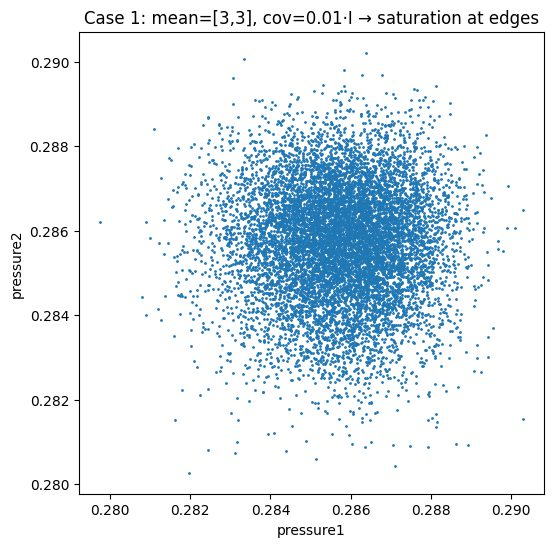

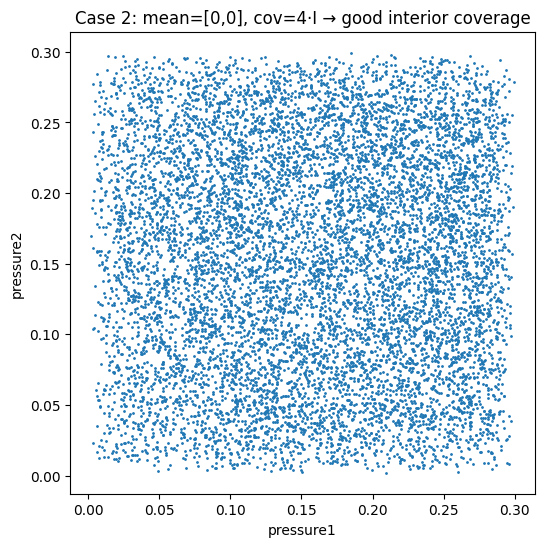

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Number of samples
N = 10000

# Pressure range
pmin, pmax = 0.0, 0.3

# Case 1: Means far from zero, small covariance → likely to saturate
mean1 = np.array([ 3.0,  3.0])
cov1  = np.eye(2) * (0.1 ** 2)

# Case 2: Means at zero, larger covariance → good coverage
mean2 = np.array([ 0.3,  0.3])
mean2 = np.random.uniform(pmin, pmax, size=(2))
print(mean2)
cov2  = np.eye(2) * 2
def sample_transformed(mean, cov, n):
    # 1) sample raw from multivariate normal
    raw = np.random.multivariate_normal(mean, cov, size=n)   # shape (n,2)
    # 2) sigmoid → (0,1)
    s   = 1 / (1 + np.exp(-raw))
    # 3) affine → [pmin,pmax]
    return pmin + s * (pmax - pmin)

# Draw samples
samps1 = sample_transformed(mean1, cov1, N)
samps2 = sample_transformed(mean2, cov2, N)

# Scatter‐plot comparison
plt.figure(figsize=(6,6))
plt.scatter(samps1[:,0], samps1[:,1], s=1)
plt.title("Case 1: mean=[3,3], cov=0.01·I → saturation at edges")
plt.xlabel("pressure1")
plt.ylabel("pressure2")

plt.figure(figsize=(6,6))
plt.scatter(samps2[:,0], samps2[:,1], s=1)
plt.title("Case 2: mean=[0,0], cov=4·I → good interior coverage")
plt.xlabel("pressure1")
plt.ylabel("pressure2")

plt.show()
